In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# pip install xgboost shap lime scikit-learn pandas numpy matplotlib

In [159]:
data=pd.read_csv("maintenance_dataset.csv")

In [160]:
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [161]:
print(data.select_dtypes(include=["number"]))

        UDI  Air temperature [K]  Process temperature [K]  \
0         1                298.1                    308.6   
1         2                298.2                    308.7   
2         3                298.1                    308.5   
3         4                298.2                    308.6   
4         5                298.2                    308.7   
...     ...                  ...                      ...   
9995   9996                298.8                    308.4   
9996   9997                298.9                    308.4   
9997   9998                299.0                    308.6   
9998   9999                299.0                    308.7   
9999  10000                299.0                    308.7   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  \
0                       1551         42.8                0                0   
1                       1408         46.3                3                0   
2                       1498  

In [162]:
data.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [163]:
data.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [164]:
data.Type.unique()

array(['M', 'L', 'H'], dtype=object)

In [165]:
# Define your target
y = data['Machine failure']

# Define your features (X)
# We drop the Target, the specific failure types, and ID columns
X = data.drop(['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'UDI', 'Product ID'], axis=1)

data.columns
X.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'],
      dtype='object')

In [166]:
X['Temp_Diff'] = X['Process temperature [K]'] - X['Air temperature [K]']

In [167]:
print(type(X))
print(X)
print(y)

<class 'pandas.core.frame.DataFrame'>
     Type  Air temperature [K]  Process temperature [K]  \
0       M                298.1                    308.6   
1       L                298.2                    308.7   
2       L                298.1                    308.5   
3       L                298.2                    308.6   
4       L                298.2                    308.7   
...   ...                  ...                      ...   
9995    M                298.8                    308.4   
9996    H                298.9                    308.4   
9997    M                299.0                    308.6   
9998    H                299.0                    308.7   
9999    M                299.0                    308.7   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Temp_Diff  
0                       1551         42.8                0       10.5  
1                       1408         46.3                3       10.5  
2                       1498         

## *Pipelining*

In [168]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
# Not Imputing coz we don't hav any missing values

numerical_cols=X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols=X.select_dtypes(include=["object"]).columns.tolist()

numerical_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy="median")),
    ('scaler',StandardScaler())
])
categorical_pipeline=Pipeline([
    ('encoding',OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))
    # ('encoding',OrdinalEncoder(handle_unknown="ignore"))
    # ('encoding',OrdinalEncoder(categories=[["L","M","H"]]),categorical_cols)
])

# Create Preprocessor
preprocessor=ColumnTransformer([
    ('num',numerical_pipeline,numerical_cols),    # perform num_pipeline on num_cols
    ('cat',categorical_pipeline,categorical_cols)  #perform cat_pipeline on cat_cols
])

#Bundle the preprocessor and model building into another pipeline
my_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',XGBClassifier(n_estimators=100,learning_rate=0.05,scale_pos_weight=28,eval_metric="logloss"))
])

> How are we encoding? 
During cross-validation, the data is split into 5 folds. There's a chance that a particular category (say H) only appears in the training fold but not in the test fold, or vice versa.
If the encoder sees a value it was never trained on, it panics and throws an error — unless you tell it what to do with unknowns.
SO, we're telling it to encode any unseen category as -1 instead of throwing an error.
- The data is imbalanced, i.e., there're more "no"s than "yes" in machine failure col
- In XGBoost, you can tell the model to treat each "Failure" (1) as if it were 28 times more important than a "Success" (0).


In [169]:
# Run cross-validation across the whole pipleine (my_pipeline)
scores = cross_val_score(my_pipeline, X, y, cv=5, scoring='f1')

print(f"Average F1 Score: {scores.mean():.4f}")

Average F1 Score: 0.5187


In [170]:
print(numerical_cols)
print(categorical_cols)
print(X.columns.tolist())
print(X.dtypes)

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff']
['Type']
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff']
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Temp_Diff                  float64
dtype: object


In [171]:
# Check class imbalance
print(y.value_counts())
print(y.value_counts(normalize=True))

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


In [172]:
# F1 alone isn't enough for imbalanced data — also check these
scoring = ['f1', 'precision', 'recall', 'roc_auc']
from sklearn.model_selection import cross_validate
results = cross_validate(my_pipeline, X, y, cv=5, scoring=scoring)
for metric, scores in results.items():
    if metric.startswith('test'):
        print(f"{metric}: {scores.mean():.4f}")

test_f1: 0.5187
test_precision: 0.4403
test_recall: 0.7369
test_roc_auc: 0.9634


> 
- Recall =73.69 (not bad)--->catches 74% of actual failures
- ROC_AUC: 0.96 ---> excellent, model is very good at ranking failures

> Precision-Recall Curve. It shows the tradeoff between "catching every failure" and "being right every time."

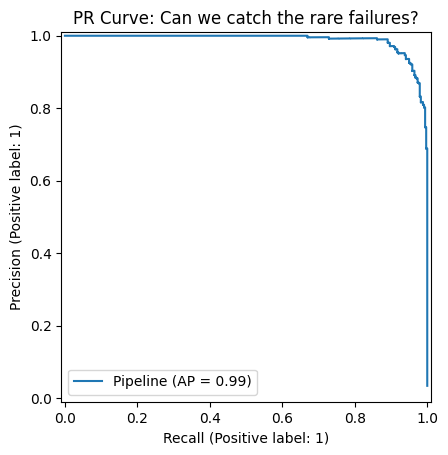

In [173]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Fit on the whole set just for the visualization
my_pipeline.fit(X, y)

PrecisionRecallDisplay.from_estimator(my_pipeline, X, y)
plt.title("PR Curve: Can we catch the rare failures?")
plt.show()

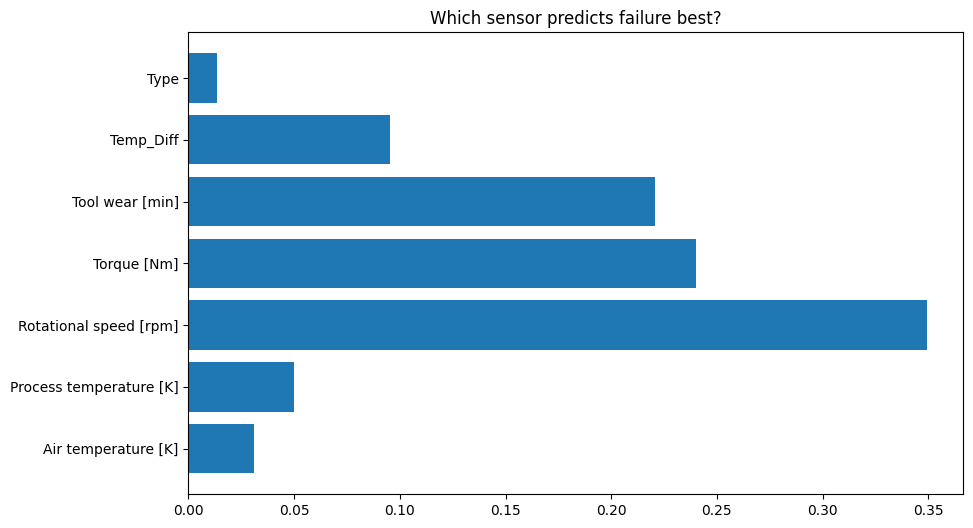

In [174]:
import matplotlib.pyplot as plt

# 1. Fit the pipeline on all data
my_pipeline.fit(X, y)

# 2. Get the XGBoost model and the feature names
model = my_pipeline.named_steps['model']
# We combine the numerical names and the categorical name 'Type'
all_features = numerical_cols + categorical_cols

# 3. Simple Plot (XGBoost Built-in)
plt.figure(figsize=(10, 6))
plt.barh(all_features, model.feature_importances_)
plt.title("Which sensor predicts failure best?")
plt.show()


# To see which is the MVP in predicting the machine failure

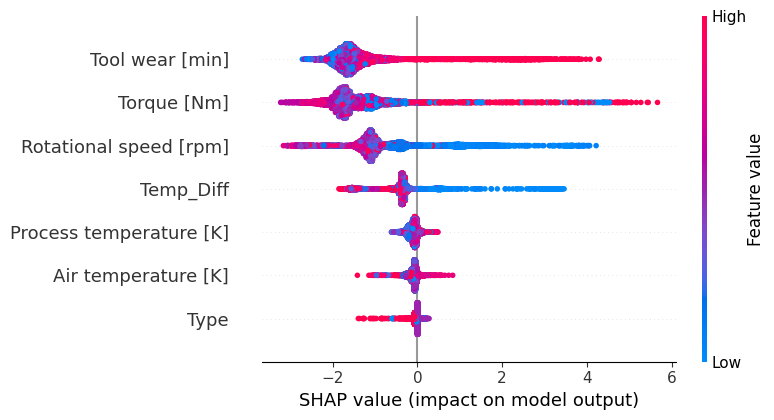

In [175]:
import shap

# 1. Create the explainer using your trained XGBoost model
# (Make sure to pass the model, not the whole pipeline)
model = my_pipeline.named_steps['model']
explainer = shap.TreeExplainer(model)

# 2. Get the transformed data from the pipeline
# We need the version that is already scaled and encoded
X_processed = my_pipeline.named_steps['preprocessor'].transform(X)

# 3. Calculate SHAP values
shap_values = explainer.shap_values(X_processed)

# 4. Plot it!
shap.summary_plot(shap_values, X_processed, feature_names=numerical_cols + categorical_cols)

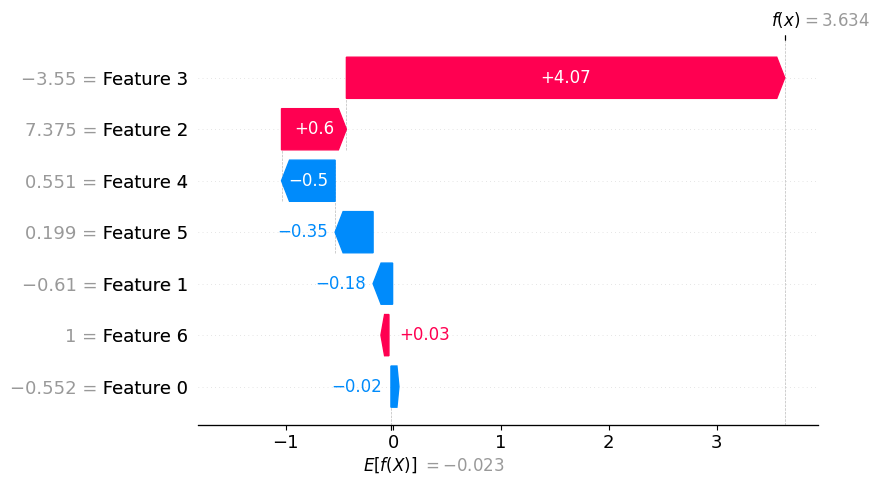

In [176]:
import shap

# 1. Define the sample index (The "Missing" part)
sample_idx = y[y == 1].index[0] 

# 2. Prepare the data for SHAP
# We use the transformed version of the whole dataset
X_transformed = my_pipeline.named_steps['preprocessor'].transform(X)

# 3. Create the explanation object
explainer = shap.TreeExplainer(my_pipeline.named_steps['model'])
explanation = explainer(X_transformed)

# 4. Plot the Waterfall for that specific failure
# We pass the processed feature names so the plot is readable
feature_names = numerical_cols + categorical_cols
shap.plots.waterfall(explanation[sample_idx])

In [177]:
def get_model_insight(pipeline, shap_explainer, input_df):
    # 1. Transform the input data using the pipeline's preprocessor
    processed_data = pipeline.named_steps['preprocessor'].transform(input_df)
    
    # 2. Get SHAP values for this specific input
    # Since it's one machine, we look at index 0
    shap_val = shap_explainer.shap_values(processed_data)[0]
    
    # 3. Map values to feature names
    feature_names = numerical_cols + categorical_cols
    feature_impacts = dict(zip(feature_names, shap_val))
    
    # 4. Sort and find the top "Risk Driver"
    # We only care about positive values (things increasing failure risk)
    top_reason = max(feature_impacts, key=feature_impacts.get)
    impact_score = feature_impacts[top_reason]
    
    if impact_score > 0:
        return f"High Risk Alert: {top_reason} is the primary driver of potential failure."
    else:
        return "System Stable: No significant failure drivers detected."

# TEST IT:
test_row = X.iloc[[sample_idx]] 
print(get_model_insight(my_pipeline, explainer, test_row))

High Risk Alert: Torque [Nm] is the primary driver of potential failure.


why joblib and not pickle?

In [185]:
import joblib

joblib.dump(my_pipeline, "maintenance_model.pkl")

['maintenance_model.pkl']

In [186]:
model = joblib.load("maintenance_model.pkl")
print(type(model))

<class 'sklearn.pipeline.Pipeline'>
